In [1]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
import os
os.chdir("/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/")

In [ ]:
root_dir = '/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/'

In [ ]:
root_data_dir = root_dir + 'data/'
raw_dir = root_data_dir + 'raw/ACN/'
preprocessed_dir = root_data_dir + 'preprocessed/ACN/'

In [ ]:
import json

**Loading 3 datasets from 3 sites**

In [ ]:
caltech_file_path = os.path.join(raw_dir, 'caltech_2018_2021.json')
with open(caltech_file_path, 'r') as file:
    caltech_data = json.load(file)

jpl_file_path = os.path.join(raw_dir, 'JPL_2018_2021.json')
with open(jpl_file_path, 'r') as file:
    jpl_data = json.load(file)

office_file_path = os.path.join(raw_dir, 'office1_2018_2021.json')
with open(office_file_path, 'r') as file:
    office_data = json.load(file)

In [ ]:
import pandas as pd

In [ ]:
caltech_df = pd.DataFrame(caltech_data['_items'])
jpl_df = pd.DataFrame(jpl_data['_items'])
office_df = pd.DataFrame(office_data['_items'])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dataframes = [caltech_df, jpl_df, office_df]

In [ ]:
for df in dataframes:
  df['connectionTime'] = pd.to_datetime(df['connectionTime'],utc=False,errors='ignore')
  df = df.sort_values('connectionTime')

**Reading Caltech Dataset**

In [ ]:
caltech_df

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
0,5bc90cb9f9af8b0d7fe77cd2,0039,2018-04-25 11:08:04+00:00,"Wed, 25 Apr 2018 13:20:10 GMT","Wed, 25 Apr 2018 13:21:10 GMT",7.932,2_39_78_362_2018-04-25 11:08:04.400812,0002,CA-496,2-39-78-362,America/Los_Angeles,None,None
1,5bc90cb9f9af8b0d7fe77cd3,0039,2018-04-25 13:45:10+00:00,"Thu, 26 Apr 2018 00:56:16 GMT","Wed, 25 Apr 2018 16:44:15 GMT",10.013,2_39_95_27_2018-04-25 13:45:09.617470,0002,CA-319,2-39-95-27,America/Los_Angeles,None,None
2,5bc90cb9f9af8b0d7fe77cd4,0039,2018-04-25 13:45:50+00:00,"Wed, 25 Apr 2018 23:04:45 GMT","Wed, 25 Apr 2018 14:51:44 GMT",5.257,2_39_79_380_2018-04-25 13:45:49.962001,0002,CA-489,2-39-79-380,America/Los_Angeles,None,None
3,5bc90cb9f9af8b0d7fe77cd5,0039,2018-04-25 14:37:06+00:00,"Wed, 25 Apr 2018 23:55:34 GMT","Wed, 25 Apr 2018 16:05:22 GMT",5.177,2_39_79_379_2018-04-25 14:37:06.460772,0002,CA-327,2-39-79-379,America/Los_Angeles,None,None
4,5bc90cb9f9af8b0d7fe77cd6,0039,2018-04-25 14:40:34+00:00,"Wed, 25 Apr 2018 23:03:12 GMT","Wed, 25 Apr 2018 17:40:30 GMT",10.119,2_39_79_381_2018-04-25 14:40:33.638896,0002,CA-490,2-39-79-381,America/Los_Angeles,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31419,61550519f9af8b76960e169a,0039,2021-09-13 21:12:53+00:00,"Tue, 14 Sep 2021 00:25:36 GMT","Mon, 13 Sep 2021 21:41:31 GMT",2.285,2_39_89_25_2021-09-13 21:12:53.318460,0002,CA-315,2-39-89-25,America/Los_Angeles,000000431,"[{'WhPerMile': 286, 'kWhRequested': 28.6, 'mil..."
31420,61550519f9af8b76960e169b,0039,2021-09-13 21:17:04+00:00,"Tue, 14 Sep 2021 01:01:49 GMT","Mon, 13 Sep 2021 23:18:07 GMT",6.715,2_39_123_23_2021-09-13 21:16:44.026068,0002,CA-313,2-39-123-23,America/Los_Angeles,000006481,"[{'WhPerMile': 460, 'kWhRequested': 11.5, 'mil..."
31421,61550519f9af8b76960e169c,0039,2021-09-13 22:33:07+00:00,"Mon, 13 Sep 2021 23:06:55 GMT",None,17.720,2_39_81_4550_2021-09-13 22:33:04.543952,0002,11900388,2-39-81-4550,America/Los_Angeles,000003905,"[{'WhPerMile': 300, 'kWhRequested': 30.0, 'mil..."
31422,61550519f9af8b76960e169d,0039,2021-09-13 23:11:12+00:00,"Tue, 14 Sep 2021 01:43:11 GMT","Tue, 14 Sep 2021 00:13:35 GMT",2.018,2_39_91_437_2021-09-13 23:10:59.528292,0002,CA-317,2-39-91-437,America/Los_Angeles,000001082,"[{'WhPerMile': 290, 'kWhRequested': 5.8, 'mile..."


**Taking the rows only where userInput is available but we have to drop around `50%` of data**

In [ ]:
caltech_df_userinput = caltech_df[caltech_df['userID'].notnull()]

# Displaying the resulting rows
caltech_df_userinput

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
222,5bc915caf9af8b0dad3c0660,0039,2018-04-30 15:07:49+00:00,"Tue, 01 May 2018 00:27:55 GMT","Tue, 01 May 2018 00:27:51 GMT",47.808,2_39_88_24_2018-04-30 15:07:48.608581,0002,CA-314,2-39-88-24,America/Los_Angeles,000000022,"[{'WhPerMile': 350, 'kWhRequested': 59.5, 'mil..."
583,5bc917d0f9af8b0dc677b8bb,0039,2018-05-07 14:38:18+00:00,"Tue, 08 May 2018 01:15:01 GMT","Tue, 08 May 2018 01:14:53 GMT",27.683,2_39_139_28_2018-05-07 14:38:17.789708,0002,CA-303,2-39-139-28,America/Los_Angeles,000000061,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
845,5bc9190ff9af8b0dc677b9c1,0039,2018-05-11 15:17:01+00:00,"Sat, 12 May 2018 00:18:43 GMT","Fri, 11 May 2018 23:05:56 GMT",17.485,2_39_88_24_2018-05-11 15:17:00.986127,0002,CA-314,2-39-88-24,America/Los_Angeles,000000022,"[{'WhPerMile': 350, 'kWhRequested': 17.5, 'mil..."
958,5bc919c3f9af8b0dc677ba32,0039,2018-05-14 13:50:26+00:00,"Mon, 14 May 2018 23:09:45 GMT","Mon, 14 May 2018 20:43:40 GMT",11.795,2_39_79_380_2018-05-14 13:50:25.765617,0002,CA-489,2-39-79-380,America/Los_Angeles,000000066,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
1006,5bc919c3f9af8b0dc677ba62,0039,2018-05-15 00:06:39+00:00,"Tue, 15 May 2018 01:13:58 GMT","Tue, 15 May 2018 00:39:01 GMT",3.076,2_39_139_28_2018-05-15 00:06:39.142568,0002,CA-303,2-39-139-28,America/Los_Angeles,000000061,"[{'WhPerMile': 250, 'kWhRequested': 5.0, 'mile..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31419,61550519f9af8b76960e169a,0039,2021-09-13 21:12:53+00:00,"Tue, 14 Sep 2021 00:25:36 GMT","Mon, 13 Sep 2021 21:41:31 GMT",2.285,2_39_89_25_2021-09-13 21:12:53.318460,0002,CA-315,2-39-89-25,America/Los_Angeles,000000431,"[{'WhPerMile': 286, 'kWhRequested': 28.6, 'mil..."
31420,61550519f9af8b76960e169b,0039,2021-09-13 21:17:04+00:00,"Tue, 14 Sep 2021 01:01:49 GMT","Mon, 13 Sep 2021 23:18:07 GMT",6.715,2_39_123_23_2021-09-13 21:16:44.026068,0002,CA-313,2-39-123-23,America/Los_Angeles,000006481,"[{'WhPerMile': 460, 'kWhRequested': 11.5, 'mil..."
31421,61550519f9af8b76960e169c,0039,2021-09-13 22:33:07+00:00,"Mon, 13 Sep 2021 23:06:55 GMT",None,17.720,2_39_81_4550_2021-09-13 22:33:04.543952,0002,11900388,2-39-81-4550,America/Los_Angeles,000003905,"[{'WhPerMile': 300, 'kWhRequested': 30.0, 'mil..."
31422,61550519f9af8b76960e169d,0039,2021-09-13 23:11:12+00:00,"Tue, 14 Sep 2021 01:43:11 GMT","Tue, 14 Sep 2021 00:13:35 GMT",2.018,2_39_91_437_2021-09-13 23:10:59.528292,0002,CA-317,2-39-91-437,America/Los_Angeles,000001082,"[{'WhPerMile': 290, 'kWhRequested': 5.8, 'mile..."


**Reading JPL Dataset**

In [ ]:
jpl_df

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
0,5c36621bf9af8b4639a8e0b4,0001,2018-09-05 11:04:13+00:00,"Wed, 05 Sep 2018 19:09:35 GMT",None,9.583,1_1_179_800_2018-09-05 11:04:12.876087,0001,AG-3F32,1-1-179-800,America/Los_Angeles,None,None
1,5c36621bf9af8b4639a8e0b5,0001,2018-09-05 11:08:09+00:00,"Wed, 05 Sep 2018 14:09:02 GMT",None,7.114,1_1_179_794_2018-09-05 11:08:08.945820,0001,AG-3F20,1-1-179-794,America/Los_Angeles,000000333,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
2,5c36621bf9af8b4639a8e0b6,0001,2018-09-05 12:35:14+00:00,"Thu, 06 Sep 2018 00:30:12 GMT",None,11.774,1_1_179_797_2018-09-05 12:35:14.070250,0001,AG-3F23,1-1-179-797,America/Los_Angeles,000000371,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
3,5c36621bf9af8b4639a8e0b7,0001,2018-09-05 12:51:31+00:00,"Wed, 05 Sep 2018 22:32:58 GMT",None,6.280,1_1_179_781_2018-09-05 12:51:31.050539,0001,AG-3F31,1-1-179-781,America/Los_Angeles,000000405,"[{'WhPerMile': 600, 'kWhRequested': 12.0, 'mil..."
4,5c36621bf9af8b4639a8e0b8,0001,2018-09-05 13:08:28+00:00,"Wed, 05 Sep 2018 23:32:52 GMT",None,7.022,1_1_179_787_2018-09-05 13:08:27.901538,0001,AG-3F16,1-1-179-787,America/Los_Angeles,000000368,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33633,6155053bf9af8b76960e16cd,0001,2021-09-13 20:10:59+00:00,"Mon, 13 Sep 2021 21:56:32 GMT","Mon, 13 Sep 2021 21:56:27 GMT",10.133,1_1_193_819_2021-09-13 20:10:43.199385,0001,AG-1F06,1-1-193-819,America/Los_Angeles,000009851,"[{'WhPerMile': 278, 'kWhRequested': 27.8, 'mil..."
33634,6155053bf9af8b76960e16ce,0001,2021-09-13 20:51:51+00:00,"Tue, 14 Sep 2021 03:17:55 GMT","Tue, 14 Sep 2021 01:34:15 GMT",23.863,1_1_193_825_2021-09-13 20:51:37.702875,0001,AG-1F01,1-1-193-825,America/Los_Angeles,000000394,"[{'WhPerMile': 283, 'kWhRequested': 28.3, 'mil..."
33635,6155053bf9af8b76960e16cf,0001,2021-09-13 21:37:59+00:00,"Tue, 14 Sep 2021 00:12:49 GMT","Tue, 14 Sep 2021 00:12:36 GMT",8.547,1_1_178_824_2021-09-13 21:37:44.554924,0001,AG-1F07,1-1-178-824,America/Los_Angeles,000003687,"[{'WhPerMile': 279, 'kWhRequested': 75.051, 'm..."
33636,6155053bf9af8b76960e16d0,0001,2021-09-14 01:08:16+00:00,"Tue, 14 Sep 2021 01:31:24 GMT","Tue, 14 Sep 2021 01:31:19 GMT",1.253,1_1_179_783_2021-09-14 01:08:03.220292,0001,AG-3F29,1-1-179-783,America/Los_Angeles,000006023,"[{'WhPerMile': 310, 'kWhRequested': 15.5, 'mil..."


**Taking the rows only where userInput is available but we have to drop around 1-2% of data**

In [ ]:
jpl_df_userinput = jpl_df[jpl_df['userID'].notnull()]

# Displaying the resulting rows
jpl_df_userinput

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
1,5c36621bf9af8b4639a8e0b5,0001,2018-09-05 11:08:09+00:00,"Wed, 05 Sep 2018 14:09:02 GMT",None,7.114,1_1_179_794_2018-09-05 11:08:08.945820,0001,AG-3F20,1-1-179-794,America/Los_Angeles,000000333,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
2,5c36621bf9af8b4639a8e0b6,0001,2018-09-05 12:35:14+00:00,"Thu, 06 Sep 2018 00:30:12 GMT",None,11.774,1_1_179_797_2018-09-05 12:35:14.070250,0001,AG-3F23,1-1-179-797,America/Los_Angeles,000000371,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
3,5c36621bf9af8b4639a8e0b7,0001,2018-09-05 12:51:31+00:00,"Wed, 05 Sep 2018 22:32:58 GMT",None,6.280,1_1_179_781_2018-09-05 12:51:31.050539,0001,AG-3F31,1-1-179-781,America/Los_Angeles,000000405,"[{'WhPerMile': 600, 'kWhRequested': 12.0, 'mil..."
4,5c36621bf9af8b4639a8e0b8,0001,2018-09-05 13:08:28+00:00,"Wed, 05 Sep 2018 23:32:52 GMT",None,7.022,1_1_179_787_2018-09-05 13:08:27.901538,0001,AG-3F16,1-1-179-787,America/Los_Angeles,000000368,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
5,5c36621bf9af8b4639a8e0b9,0001,2018-09-05 13:10:14+00:00,"Wed, 05 Sep 2018 22:21:44 GMT",None,13.282,1_1_179_798_2018-09-05 13:10:13.879377,0001,AG-3F18,1-1-179-798,America/Los_Angeles,000000334,"[{'WhPerMile': 400, 'kWhRequested': 20.0, 'mil..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33633,6155053bf9af8b76960e16cd,0001,2021-09-13 20:10:59+00:00,"Mon, 13 Sep 2021 21:56:32 GMT","Mon, 13 Sep 2021 21:56:27 GMT",10.133,1_1_193_819_2021-09-13 20:10:43.199385,0001,AG-1F06,1-1-193-819,America/Los_Angeles,000009851,"[{'WhPerMile': 278, 'kWhRequested': 27.8, 'mil..."
33634,6155053bf9af8b76960e16ce,0001,2021-09-13 20:51:51+00:00,"Tue, 14 Sep 2021 03:17:55 GMT","Tue, 14 Sep 2021 01:34:15 GMT",23.863,1_1_193_825_2021-09-13 20:51:37.702875,0001,AG-1F01,1-1-193-825,America/Los_Angeles,000000394,"[{'WhPerMile': 283, 'kWhRequested': 28.3, 'mil..."
33635,6155053bf9af8b76960e16cf,0001,2021-09-13 21:37:59+00:00,"Tue, 14 Sep 2021 00:12:49 GMT","Tue, 14 Sep 2021 00:12:36 GMT",8.547,1_1_178_824_2021-09-13 21:37:44.554924,0001,AG-1F07,1-1-178-824,America/Los_Angeles,000003687,"[{'WhPerMile': 279, 'kWhRequested': 75.051, 'm..."
33636,6155053bf9af8b76960e16d0,0001,2021-09-14 01:08:16+00:00,"Tue, 14 Sep 2021 01:31:24 GMT","Tue, 14 Sep 2021 01:31:19 GMT",1.253,1_1_179_783_2021-09-14 01:08:03.220292,0001,AG-3F29,1-1-179-783,America/Los_Angeles,000006023,"[{'WhPerMile': 310, 'kWhRequested': 15.5, 'mil..."


**Reading Office Dataset**

In [ ]:
office_df

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
0,5cd1d47af9af8b68f0e96713,0102,2019-03-25 16:24:42+00:00,"Tue, 26 Mar 2019 01:32:12 GMT","Mon, 25 Mar 2019 17:32:48 GMT",6.146,19_102_260_1633_2019-03-25 16:24:42.408146,0019,02,19-102-260-1633,America/Los_Angeles,None,None
1,5cd1d47af9af8b68f0e96714,0102,2019-03-25 17:19:27+00:00,"Tue, 26 Mar 2019 00:38:50 GMT","Mon, 25 Mar 2019 18:00:49 GMT",3.658,19_102_260_1634_2019-03-25 17:19:26.896309,0019,03,19-102-260-1634,America/Los_Angeles,None,None
2,5cd1d47af9af8b68f0e96715,0102,2019-03-25 21:27:32+00:00,"Tue, 26 Mar 2019 03:32:03 GMT","Tue, 26 Mar 2019 02:10:40 GMT",28.330,19_102_260_1640_2019-03-25 21:27:32.338192,0019,08,19-102-260-1640,America/Los_Angeles,None,None
3,5cd1d47df9af8b68f0e96716,0102,2019-03-26 18:33:56+00:00,"Wed, 27 Mar 2019 00:45:33 GMT","Tue, 26 Mar 2019 22:30:58 GMT",12.978,19_102_260_1640_2019-03-26 18:33:56.204855,0019,08,19-102-260-1640,America/Los_Angeles,None,None
4,5cd1d47ef9af8b68f0e96717,0102,2019-03-27 18:28:01+00:00,"Thu, 28 Mar 2019 00:37:47 GMT","Wed, 27 Mar 2019 21:44:03 GMT",10.688,19_102_260_1640_2019-03-27 18:28:00.642220,0019,08,19-102-260-1640,America/Los_Angeles,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1678,614fbf0df9af8b6e4f11442d,0102,2021-09-09 21:11:44+00:00,"Fri, 10 Sep 2021 03:47:58 GMT","Fri, 10 Sep 2021 03:47:33 GMT",19.342,19_102_260_1640_2021-09-09 21:11:26.620176,0019,08,19-102-260-1640,America/Los_Angeles,000006140,"[{'WhPerMile': 258, 'kWhRequested': 72.24, 'mi..."
1679,6151108ff9af8b70789b4fed,0102,2021-09-10 15:33:08+00:00,"Fri, 10 Sep 2021 23:53:29 GMT","Fri, 10 Sep 2021 22:49:37 GMT",33.186,19_102_260_1634_2021-09-10 15:32:59.042125,0019,03,19-102-260-1634,America/Los_Angeles,000006620,"[{'WhPerMile': 1428, 'kWhRequested': 114.24, '..."
1680,6151108ff9af8b70789b4fee,0102,2021-09-10 21:12:26+00:00,"Sat, 11 Sep 2021 04:25:47 GMT","Sat, 11 Sep 2021 04:25:34 GMT",19.894,19_102_260_1640_2021-09-10 21:12:15.541083,0019,08,19-102-260-1640,America/Los_Angeles,000006140,"[{'WhPerMile': 258, 'kWhRequested': 72.24, 'mi..."
1681,61550514f9af8b76948f5921,0102,2021-09-13 17:35:32+00:00,"Tue, 14 Sep 2021 00:26:25 GMT","Tue, 14 Sep 2021 00:26:05 GMT",26.688,19_102_260_1634_2021-09-13 17:35:24.605831,0019,03,19-102-260-1634,America/Los_Angeles,000006620,"[{'WhPerMile': 1428, 'kWhRequested': 114.24, '..."


**Taking the rows only where userInput is available but we have to drop around 60% of data**

In [ ]:
office_df_userinput = office_df[office_df['userID'].notnull()]

# Displaying the resulting rows
office_df_userinput

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
1094,5e571b9ff9af8b7a23b4d6dc,0102,2020-02-10 20:54:47+00:00,"Tue, 11 Feb 2020 04:45:26 GMT","Tue, 11 Feb 2020 04:45:06 GMT",26.221,19_102_260_1640_2020-02-10 20:54:47.381201,0019,08,19-102-260-1640,America/Los_Angeles,000006140,"[{'WhPerMile': 400, 'kWhRequested': 20.0, 'mil..."
1095,5e586d1ef9af8b7ddcb15422,0102,2020-02-11 15:46:05+00:00,"Tue, 11 Feb 2020 20:30:21 GMT","Tue, 11 Feb 2020 18:17:04 GMT",3.905,19_102_260_1633_2020-02-11 15:46:05.429283,0019,02,19-102-260-1633,America/Los_Angeles,000006062,"[{'WhPerMile': 350, 'kWhRequested': 7.0, 'mile..."
1096,5e586d1ef9af8b7ddcb15423,0102,2020-02-11 18:26:55+00:00,"Wed, 12 Feb 2020 01:45:51 GMT","Wed, 12 Feb 2020 01:45:38 GMT",33.223,19_102_260_1638_2020-02-11 18:26:55.139967,0019,04,19-102-260-1638,America/Los_Angeles,000006171,"[{'WhPerMile': 250, 'kWhRequested': 25.0, 'mil..."
1097,5e59be9ff9af8b02eb78f15c,0102,2020-02-12 15:21:31+00:00,"Thu, 13 Feb 2020 02:36:50 GMT","Wed, 12 Feb 2020 19:33:43 GMT",4.122,19_102_260_1633_2020-02-12 15:21:31.310707,0019,02,19-102-260-1633,America/Los_Angeles,000006062,"[{'WhPerMile': 350, 'kWhRequested': 7.0, 'mile..."
1098,5e59be9ff9af8b02eb78f15d,0102,2020-02-12 18:36:30+00:00,"Wed, 12 Feb 2020 20:40:06 GMT","Wed, 12 Feb 2020 20:40:02 GMT",5.261,19_102_260_1640_2020-02-12 18:36:30.222576,0019,08,19-102-260-1640,America/Los_Angeles,000004400,"[{'WhPerMile': 400, 'kWhRequested': 12.0, 'mil..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1678,614fbf0df9af8b6e4f11442d,0102,2021-09-09 21:11:44+00:00,"Fri, 10 Sep 2021 03:47:58 GMT","Fri, 10 Sep 2021 03:47:33 GMT",19.342,19_102_260_1640_2021-09-09 21:11:26.620176,0019,08,19-102-260-1640,America/Los_Angeles,000006140,"[{'WhPerMile': 258, 'kWhRequested': 72.24, 'mi..."
1679,6151108ff9af8b70789b4fed,0102,2021-09-10 15:33:08+00:00,"Fri, 10 Sep 2021 23:53:29 GMT","Fri, 10 Sep 2021 22:49:37 GMT",33.186,19_102_260_1634_2021-09-10 15:32:59.042125,0019,03,19-102-260-1634,America/Los_Angeles,000006620,"[{'WhPerMile': 1428, 'kWhRequested': 114.24, '..."
1680,6151108ff9af8b70789b4fee,0102,2021-09-10 21:12:26+00:00,"Sat, 11 Sep 2021 04:25:47 GMT","Sat, 11 Sep 2021 04:25:34 GMT",19.894,19_102_260_1640_2021-09-10 21:12:15.541083,0019,08,19-102-260-1640,America/Los_Angeles,000006140,"[{'WhPerMile': 258, 'kWhRequested': 72.24, 'mi..."
1681,61550514f9af8b76948f5921,0102,2021-09-13 17:35:32+00:00,"Tue, 14 Sep 2021 00:26:25 GMT","Tue, 14 Sep 2021 00:26:05 GMT",26.688,19_102_260_1634_2021-09-13 17:35:24.605831,0019,03,19-102-260-1634,America/Los_Angeles,000006620,"[{'WhPerMile': 1428, 'kWhRequested': 114.24, '..."


**taking rows only more than energy delivered 40KWh for Caltech and the
percentage is very low**

In [ ]:
# Filter rows where kWhDelivered is more than 40
jpl_filtered_df = jpl_df_userinput[jpl_df_userinput['kWhDelivered'] > 40]

# Extract "day" and "time" from "connectionTime" column using .loc
jpl_filtered_df.loc[:, 'day'] = jpl_filtered_df['connectionTime'].dt.strftime('%A')
jpl_filtered_df.loc[:, 'time'] = jpl_filtered_df['connectionTime'].dt.time

# Select "userID", "day", and "time" columns
jpl_result = jpl_filtered_df[['kWhDelivered','userID', 'day', 'time']]

# Display the result
jpl_result

<ipython-input-89-d4f384096618>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jpl_filtered_df.loc[:, 'day'] = filtered_df['connectionTime'].dt.strftime('%A')
<ipython-input-89-d4f384096618>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jpl_filtered_df.loc[:, 'time'] = filtered_df['connectionTime'].dt.time


,kWhDelivered,userID,day,time
76,45.336,000000389,Friday,13:00:23
394,44.942,000000387,Wednesday,14:37:04
571,41.063,000000439,Monday,12:57:46
591,48.632,000000403,Monday,14:36:32
705,44.252,000000387,Wednesday,14:08:32
...,...,...,...,...
33527,50.536,000019652,Thursday,15:07:51
33589,41.012,000006453,Monday,12:28:25
33603,47.709,000011775,Monday,14:44:00
33609,54.036,000000374,Monday,15:18:34


**taking rows only more than energy delivered 40KWh for Caltech and the
percentage is very low**

In [ ]:
# Filter rows where kWhDelivered is more than 40
caltech_filtered_df = caltech_df_userinput[caltech_df_userinput['kWhDelivered'] > 40]

# Extract "day" and "time" from "connectionTime" column using .loc
caltech_filtered_df.loc[:, 'day'] = caltech_filtered_df['connectionTime'].dt.strftime('%A')
caltech_filtered_df.loc[:, 'time'] = caltech_filtered_df['connectionTime'].dt.time

# Select "userID", "day", and "time" columns
caltech_result = caltech_filtered_df[['kWhDelivered','userID', 'day', 'time']]

# Display the result
caltech_result

<ipython-input-90-ad59fd098aa5>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  caltech_filtered_df.loc[:, 'day'] = caltech_filtered_df['connectionTime'].dt.strftime('%A')
<ipython-input-90-ad59fd098aa5>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  caltech_filtered_df.loc[:, 'time'] = caltech_filtered_df['connectionTime'].dt.time


,kWhDelivered,userID,day,time
222,47.808,000000022,Monday,15:07:49
3854,41.668,000000067,Saturday,08:28:20
4396,45.735,000000067,Tuesday,05:04:50
6072,45.398,000000058,Thursday,19:03:05
6343,50.525,000000216,Monday,16:38:09
...,...,...,...,...
31403,53.024,000018113,Monday,15:25:32
31404,43.353,000015724,Monday,15:33:00
31412,41.052,000015895,Monday,17:46:26
31418,49.136,000000609,Monday,20:26:50


**taking rows only more than energy delivered 40KWh for Office and the
percentage is very low**

In [ ]:
# Filter rows where kWhDelivered is more than 40
office_filtered_df = office_df_userinput[office_df_userinput['kWhDelivered'] > 40]

# Extract "day" and "time" from "connectionTime" column using .loc
office_filtered_df.loc[:, 'day'] = office_filtered_df['connectionTime'].dt.strftime('%A')
office_filtered_df.loc[:, 'time'] = office_filtered_df['connectionTime'].dt.time

# Select "userID", "day", and "time" columns
office_result = office_filtered_df[['kWhDelivered','userID', 'day', 'time']]

# Display the result
office_result

<ipython-input-91-6a8811828c34>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  office_filtered_df.loc[:, 'day'] = office_filtered_df['connectionTime'].dt.strftime('%A')
<ipython-input-91-6a8811828c34>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  office_filtered_df.loc[:, 'time'] = office_filtered_df['connectionTime'].dt.time


,kWhDelivered,userID,day,time
1103,40.008,000003618,Thursday,15:35:57
1139,44.971,000003618,Monday,15:36:42
1233,42.945,000006140,Tuesday,01:02:50
1243,65.214,000006140,Monday,16:00:13
1251,49.115,000006140,Thursday,16:36:52
1267,60.860,000006140,Friday,23:20:26
1274,44.054,000006140,Tuesday,23:13:28
1279,59.012,000006140,Wednesday,19:58:05
1295,59.804,000006140,Monday,19:55:46
1310,57.958,000006140,Thursday,20:26:51


**A stacked bar plot showing the energy delivered by each user on each day, based on the 'kWhDelivered' data of the 'office_result' DataFrame.**

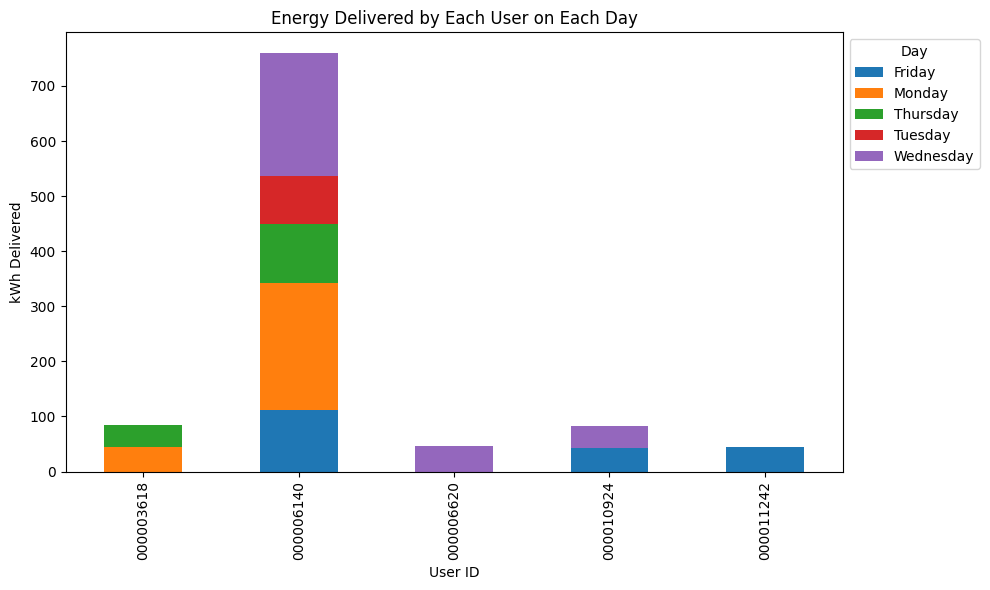

In [ ]:
import matplotlib.pyplot as plt

# Group the data by 'userID' and 'day' and calculate the sum of 'kWhDelivered' for each group
grouped_data = office_result.groupby(['userID', 'day'])['kWhDelivered'].sum().reset_index()

# Pivot the data to have 'day' as columns and 'userID' as index
pivot_data = grouped_data.pivot(index='userID', columns='day', values='kWhDelivered')

# Plot the bar plot
pivot_data.plot(kind='bar', stacked=True, figsize=(10, 6))

# Add labels and title
plt.xlabel('User ID')
plt.ylabel('kWh Delivered')
plt.title('Energy Delivered by Each User on Each Day')

# Show the plot
plt.legend(title='Day', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

**A grouped bar plot displaying the number of unique users and total energy delivered per day**

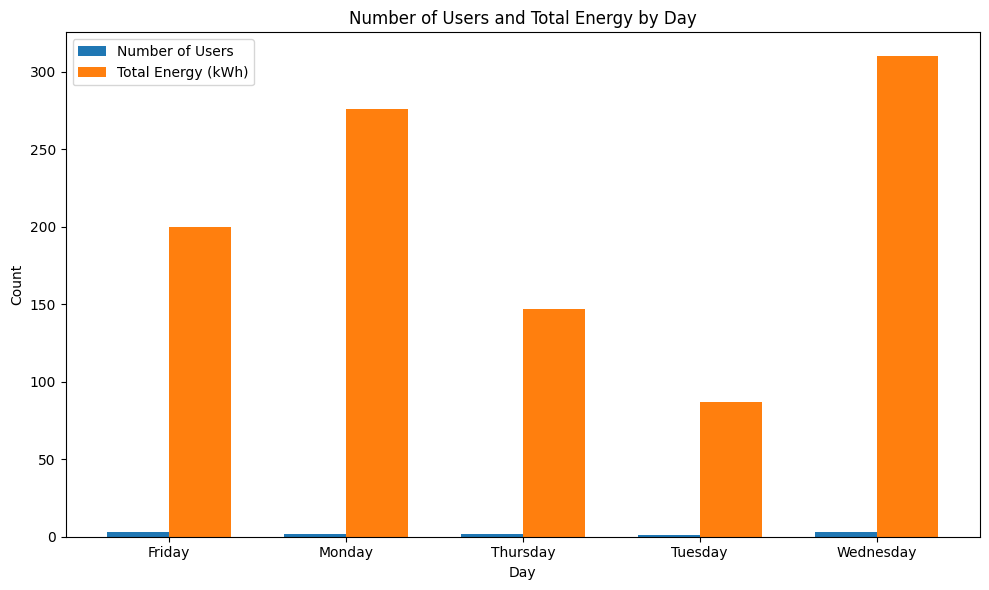

In [ ]:
import matplotlib.pyplot as plt

# Group the data by 'day', count the number of unique users ('userID') and sum the 'kWhDelivered' for each day
grouped_data = office_result.groupby('day').agg({'userID': 'nunique', 'kWhDelivered': 'sum'}).reset_index()
grouped_data.rename(columns={'userID': 'NumUsers'}, inplace=True)

# Plot the grouped bar plot
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = range(len(grouped_data))

ax.bar(index, grouped_data['NumUsers'], bar_width, label='Number of Users')
ax.bar([i + bar_width for i in index], grouped_data['kWhDelivered'], bar_width, label='Total Energy (kWh)')

# Add labels and title
plt.xlabel('Day')
plt.ylabel('Count')
plt.title('Number of Users and Total Energy by Day')
plt.xticks([i + bar_width/2 for i in index], grouped_data['day'])
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

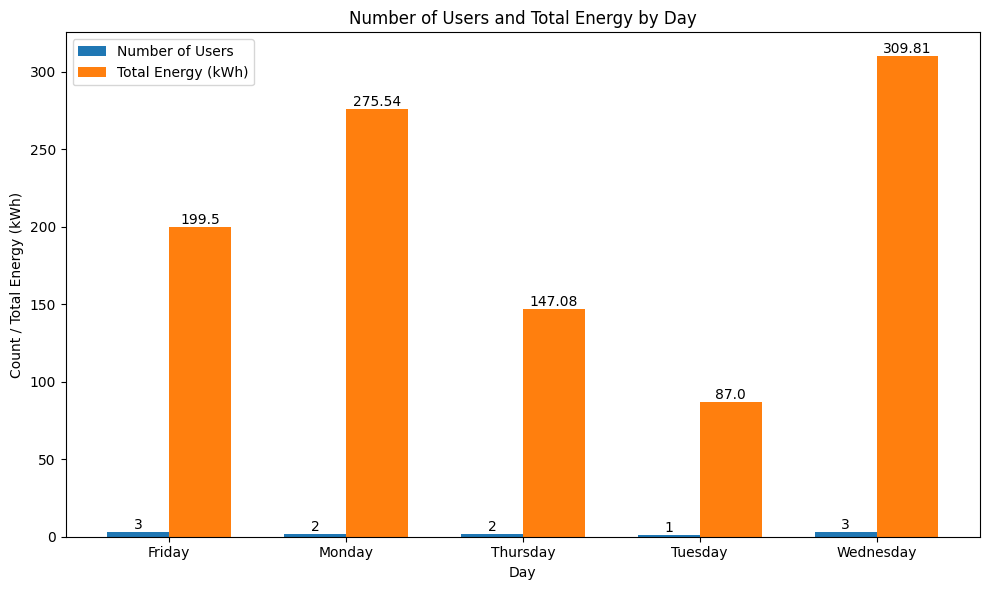

In [ ]:
import matplotlib.pyplot as plt

# Group the data by 'day', count the number of unique users ('userID') and sum the 'kWhDelivered' for each day
grouped_data = office_result.groupby('day').agg({'userID': ['nunique', lambda x: ', '.join(x.unique())], 'kWhDelivered': 'sum'}).reset_index()
grouped_data.columns = ['day', 'NumUsers', 'UserIDs', 'TotalEnergy']

# Plot the grouped bar plot
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = range(len(grouped_data))

ax.bar(index, grouped_data['NumUsers'], bar_width, label='Number of Users')
ax.bar([i + bar_width for i in index], grouped_data['TotalEnergy'], bar_width, label='Total Energy (kWh)')

# Add value and user ID annotations
for i, value in enumerate(grouped_data['NumUsers']):
    ax.text(i, value, str(value), ha='center', va='bottom')

for i, value in enumerate(grouped_data['TotalEnergy']):
    ax.text(i + bar_width, value, str(round(value, 2)), ha='center', va='bottom')

# Add labels and title
plt.xlabel('Day')
plt.ylabel('Count / Total Energy (kWh)')
plt.title('Number of Users and Total Energy by Day')
plt.xticks([i + bar_width/2 for i in index], grouped_data['day'])
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

**A grouped bar plot displaying the number of unique users and total energy delivered per day jpl**

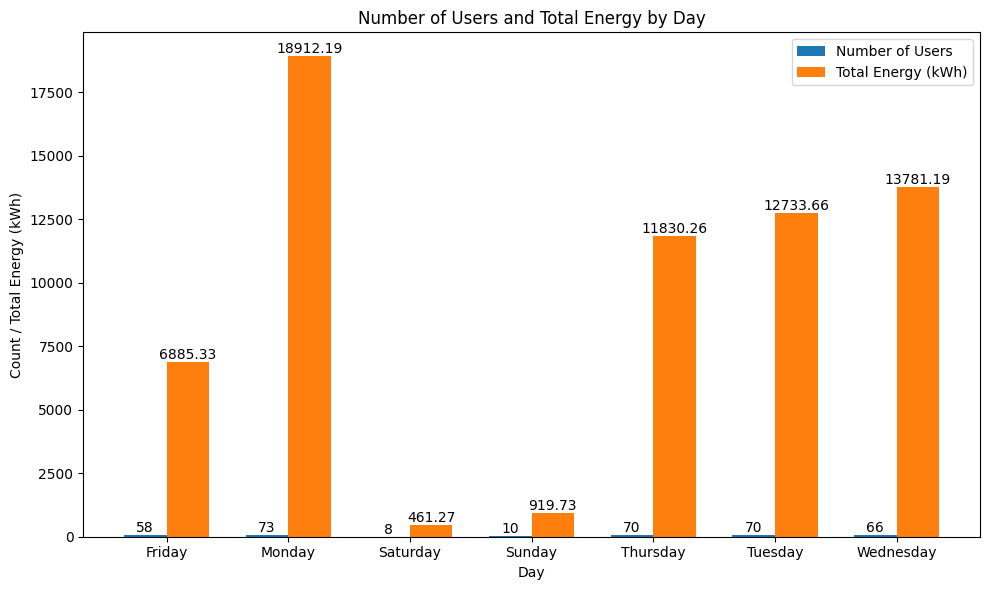

In [ ]:
import matplotlib.pyplot as plt

# Group the data by 'day', count the number of unique users ('userID') and sum the 'kWhDelivered' for each day
grouped_data = jpl_result.groupby('day').agg({'userID': ['nunique', lambda x: ', '.join(x.unique())], 'kWhDelivered': 'sum'}).reset_index()
grouped_data.columns = ['day', 'NumUsers', 'UserIDs', 'TotalEnergy']

# Plot the grouped bar plot
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = range(len(grouped_data))

ax.bar(index, grouped_data['NumUsers'], bar_width, label='Number of Users')
ax.bar([i + bar_width for i in index], grouped_data['TotalEnergy'], bar_width, label='Total Energy (kWh)')

# Add value and user ID annotations
for i, value in enumerate(grouped_data['NumUsers']):
    ax.text(i, value, str(value), ha='center', va='bottom')

for i, value in enumerate(grouped_data['TotalEnergy']):
    ax.text(i + bar_width, value, str(round(value, 2)), ha='center', va='bottom')

# Add labels and title
plt.xlabel('Day')
plt.ylabel('Count / Total Energy (kWh)')
plt.title('Number of Users and Total Energy by Day')
plt.xticks([i + bar_width/2 for i in index], grouped_data['day'])
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

**A grouped bar plot displaying the number of unique users and total energy delivered per day caltech**

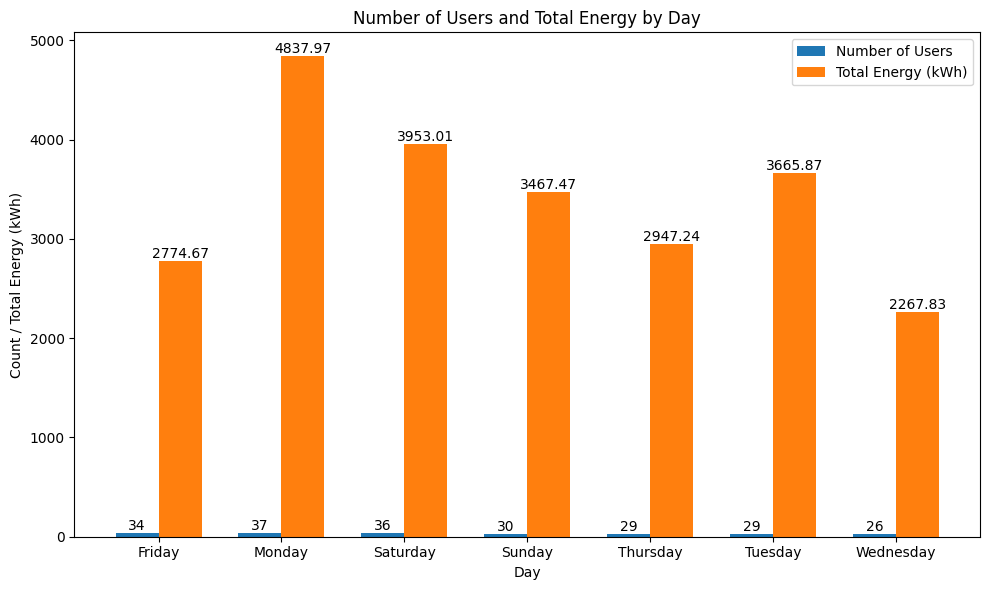

In [ ]:
import matplotlib.pyplot as plt

# Group the data by 'day', count the number of unique users ('userID') and sum the 'kWhDelivered' for each day
grouped_data = caltech_result.groupby('day').agg({'userID': ['nunique', lambda x: ', '.join(x.unique())], 'kWhDelivered': 'sum'}).reset_index()
grouped_data.columns = ['day', 'NumUsers', 'UserIDs', 'TotalEnergy']

# Plot the grouped bar plot
fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.35
index = range(len(grouped_data))

ax.bar(index, grouped_data['NumUsers'], bar_width, label='Number of Users')
ax.bar([i + bar_width for i in index], grouped_data['TotalEnergy'], bar_width, label='Total Energy (kWh)')

# Add value and user ID annotations
for i, value in enumerate(grouped_data['NumUsers']):
    ax.text(i, value, str(value), ha='center', va='bottom')

for i, value in enumerate(grouped_data['TotalEnergy']):
    ax.text(i + bar_width, value, str(round(value, 2)), ha='center', va='bottom')

# Add labels and title
plt.xlabel('Day')
plt.ylabel('Count / Total Energy (kWh)')
plt.title('Number of Users and Total Energy by Day')
plt.xticks([i + bar_width/2 for i in index], grouped_data['day'])
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
user_inputs = [caltech_df_userinput, jpl_df_userinput, office_df_userinput]

In [ ]:
caltech_df_userinput

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
222,5bc915caf9af8b0dad3c0660,0039,2018-04-30 15:07:49+00:00,"Tue, 01 May 2018 00:27:55 GMT","Tue, 01 May 2018 00:27:51 GMT",47.808,2_39_88_24_2018-04-30 15:07:48.608581,0002,CA-314,2-39-88-24,America/Los_Angeles,000000022,"[{'WhPerMile': 350, 'kWhRequested': 59.5, 'mil..."
583,5bc917d0f9af8b0dc677b8bb,0039,2018-05-07 14:38:18+00:00,"Tue, 08 May 2018 01:15:01 GMT","Tue, 08 May 2018 01:14:53 GMT",27.683,2_39_139_28_2018-05-07 14:38:17.789708,0002,CA-303,2-39-139-28,America/Los_Angeles,000000061,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
845,5bc9190ff9af8b0dc677b9c1,0039,2018-05-11 15:17:01+00:00,"Sat, 12 May 2018 00:18:43 GMT","Fri, 11 May 2018 23:05:56 GMT",17.485,2_39_88_24_2018-05-11 15:17:00.986127,0002,CA-314,2-39-88-24,America/Los_Angeles,000000022,"[{'WhPerMile': 350, 'kWhRequested': 17.5, 'mil..."
958,5bc919c3f9af8b0dc677ba32,0039,2018-05-14 13:50:26+00:00,"Mon, 14 May 2018 23:09:45 GMT","Mon, 14 May 2018 20:43:40 GMT",11.795,2_39_79_380_2018-05-14 13:50:25.765617,0002,CA-489,2-39-79-380,America/Los_Angeles,000000066,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
1006,5bc919c3f9af8b0dc677ba62,0039,2018-05-15 00:06:39+00:00,"Tue, 15 May 2018 01:13:58 GMT","Tue, 15 May 2018 00:39:01 GMT",3.076,2_39_139_28_2018-05-15 00:06:39.142568,0002,CA-303,2-39-139-28,America/Los_Angeles,000000061,"[{'WhPerMile': 250, 'kWhRequested': 5.0, 'mile..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31419,61550519f9af8b76960e169a,0039,2021-09-13 21:12:53+00:00,"Tue, 14 Sep 2021 00:25:36 GMT","Mon, 13 Sep 2021 21:41:31 GMT",2.285,2_39_89_25_2021-09-13 21:12:53.318460,0002,CA-315,2-39-89-25,America/Los_Angeles,000000431,"[{'WhPerMile': 286, 'kWhRequested': 28.6, 'mil..."
31420,61550519f9af8b76960e169b,0039,2021-09-13 21:17:04+00:00,"Tue, 14 Sep 2021 01:01:49 GMT","Mon, 13 Sep 2021 23:18:07 GMT",6.715,2_39_123_23_2021-09-13 21:16:44.026068,0002,CA-313,2-39-123-23,America/Los_Angeles,000006481,"[{'WhPerMile': 460, 'kWhRequested': 11.5, 'mil..."
31421,61550519f9af8b76960e169c,0039,2021-09-13 22:33:07+00:00,"Mon, 13 Sep 2021 23:06:55 GMT",None,17.720,2_39_81_4550_2021-09-13 22:33:04.543952,0002,11900388,2-39-81-4550,America/Los_Angeles,000003905,"[{'WhPerMile': 300, 'kWhRequested': 30.0, 'mil..."
31422,61550519f9af8b76960e169d,0039,2021-09-13 23:11:12+00:00,"Tue, 14 Sep 2021 01:43:11 GMT","Tue, 14 Sep 2021 00:13:35 GMT",2.018,2_39_91_437_2021-09-13 23:10:59.528292,0002,CA-317,2-39-91-437,America/Los_Angeles,000001082,"[{'WhPerMile': 290, 'kWhRequested': 5.8, 'mile..."


In [ ]:
caltech_normalized_df = pd.json_normalize(caltech_df_userinput['userInputs'])

# Concatenate the normalized DataFrame with the original DataFrame
caltech_df = pd.concat([df, caltech_normalized_df], axis=1)

In [ ]:
caltech_df = caltech_df_userinput['userInputs']
jpl_df = jpl_df_userinput['userInputs']
office_df = office_df_userinput['userInputs']

In [ ]:
caltech_df

222      [{'WhPerMile': 350, 'kWhRequested': 59.5, 'mil...
583      [{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...
845      [{'WhPerMile': 350, 'kWhRequested': 17.5, 'mil...
958      [{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...
1006     [{'WhPerMile': 250, 'kWhRequested': 5.0, 'mile...
                               ...                        
31419    [{'WhPerMile': 286, 'kWhRequested': 28.6, 'mil...
31420    [{'WhPerMile': 460, 'kWhRequested': 11.5, 'mil...
31421    [{'WhPerMile': 300, 'kWhRequested': 30.0, 'mil...
31422    [{'WhPerMile': 290, 'kWhRequested': 5.8, 'mile...
31423    [{'WhPerMile': 286, 'kWhRequested': 28.6, 'mil...
Name: userInputs, Length: 16388, dtype: object

In [ ]:
caltech_df.info()

<class 'pandas.core.series.Series'>
Int64Index: 16388 entries, 222 to 31423
Series name: userInputs
Non-Null Count  Dtype 
--------------  ----- 
16388 non-null  object
dtypes: object(1)
memory usage: 256.1+ KB


In [ ]:
df1 = pd.DataFrame({'userInputs': caltech_df.tolist()})
df2 = pd.DataFrame({'userInputs': jpl_df.tolist()})
df3 = pd.DataFrame({'userInputs': office_df.tolist()})

In [ ]:
df1

,userInputs
0,"[{'WhPerMile': 350, 'kWhRequested': 59.5, 'mil..."
1,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
2,"[{'WhPerMile': 350, 'kWhRequested': 17.5, 'mil..."
3,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
4,"[{'WhPerMile': 250, 'kWhRequested': 5.0, 'mile..."
...,...
16383,"[{'WhPerMile': 286, 'kWhRequested': 28.6, 'mil..."
16384,"[{'WhPerMile': 460, 'kWhRequested': 11.5, 'mil..."
16385,"[{'WhPerMile': 300, 'kWhRequested': 30.0, 'mil..."
16386,"[{'WhPerMile': 290, 'kWhRequested': 5.8, 'mile..."


In [ ]:
df_list = [df1, df2, df3]

**UserInput analysis for all the df**

In [ ]:
result_dfs = [pd.DataFrame({'userInputs': df['userInputs'].tolist()}) for df in df_list]

for result_df in result_dfs:
    result_df['WhPerMile'] = result_df['userInputs'].apply(lambda x: x[0]['WhPerMile'])
    result_df['kWhRequested'] = result_df['userInputs'].apply(lambda x: x[0]['kWhRequested'])
    result_df['milesRequested'] = result_df['userInputs'].apply(lambda x: x[0]['milesRequested'])
    result_df['minutesAvailable'] = result_df['userInputs'].apply(lambda x: x[0]['minutesAvailable'])
    result_df['modifiedAt'] = result_df['userInputs'].apply(lambda x: x[0]['modifiedAt'])
    result_df['paymentRequired'] = result_df['userInputs'].apply(lambda x: x[0]['paymentRequired'])
    result_df['requestedDeparture'] = result_df['userInputs'].apply(lambda x: x[0]['requestedDeparture'])
    result_df['userID'] = result_df['userInputs'].apply(lambda x: x[0]['userID'])

In [ ]:
result_df1 = result_dfs[0]  # Access the first resulting DataFrame
result_df2 = result_dfs[1]  # Access the second resulting DataFrame
result_df3 = result_dfs[2]  # Access the third resulting DataFrame

In [ ]:
result_df1

,userInputs,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID
0,"[{'WhPerMile': 350, 'kWhRequested': 59.5, 'mil...",350,59.5,170,550,"Mon, 30 Apr 2018 15:08:54 GMT",True,"Tue, 01 May 2018 00:17:49 GMT",22
1,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",400,8.0,20,60,"Mon, 07 May 2018 14:38:32 GMT",True,"Mon, 07 May 2018 15:38:18 GMT",61
2,"[{'WhPerMile': 350, 'kWhRequested': 17.5, 'mil...",350,17.5,50,546,"Fri, 11 May 2018 15:18:23 GMT",True,"Sat, 12 May 2018 00:23:01 GMT",22
3,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",400,8.0,20,60,"Mon, 14 May 2018 13:51:52 GMT",True,"Mon, 14 May 2018 14:50:26 GMT",66
4,"[{'WhPerMile': 250, 'kWhRequested': 5.0, 'mile...",250,5.0,20,611,"Tue, 15 May 2018 00:06:56 GMT",True,"Tue, 15 May 2018 10:17:39 GMT",61
...,...,...,...,...,...,...,...,...,...
16383,"[{'WhPerMile': 286, 'kWhRequested': 28.6, 'mil...",286,28.6,100,480,"Mon, 13 Sep 2021 21:13:32 GMT",True,"Tue, 14 Sep 2021 05:12:53 GMT",431
16384,"[{'WhPerMile': 460, 'kWhRequested': 11.5, 'mil...",460,11.5,25,107,"Mon, 13 Sep 2021 21:17:04 GMT",True,"Mon, 13 Sep 2021 23:04:04 GMT",6481
16385,"[{'WhPerMile': 300, 'kWhRequested': 30.0, 'mil...",300,30.0,100,288,"Mon, 13 Sep 2021 22:33:07 GMT",True,"Tue, 14 Sep 2021 03:21:07 GMT",3905
16386,"[{'WhPerMile': 290, 'kWhRequested': 5.8, 'mile...",290,5.8,20,120,"Mon, 13 Sep 2021 23:11:12 GMT",True,"Tue, 14 Sep 2021 01:11:12 GMT",1082
